In [110]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [111]:
data = pd.read_csv("data/mnist_train.csv", header=None)
data = np.array(data) # matrix of 60000 (samples) x 785 (features + 1 label) entries
m, n = data.shape # m = 60000, n = 785
np.random.shuffle(data)

In [112]:
data_dev = data[0:1000].T # we get a matrix of 785 rows and 1000 columns where the first row has labels, all other row has pixel values and each column is one sample
Y_dev = data_dev[0] # target values, first row
X_dev = data_dev[1:n] # all rows except the first one
X_dev = X_dev/255

data_train = data[1000:m].T # matrix of 785 rows and 59000 columns
Y_train = data_train[0] # vector of 59000 values
X_train = data_train[1:n] # matrix of 785 rows and 59000 columns
X_train = X_train/255

In [113]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

def ReLU(z):
    return np.maximum(0, z)

def deriv_ReLU(z):
    return z > 0

def softmax(z):
    prob = np.exp(z)/sum(np.exp(z))
    return prob

def forward_prop(W1, b1, W2, b2, X):
    z1 = W1.dot(X) + b1
    A1 = ReLU(z1)
    z2 = W2.dot(A1) + b2
    A2= softmax(z2)
    return z1, A1, z2, A2

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max()+1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def back_prop(z1, A1, z2, A2, W1, W2, X, Y):
    m = Y.size
    one_hot_Y = one_hot(Y)
    dz2 = A2 - one_hot_Y
    dW2 = 1/ m * dz2.dot(A1.T)
    db2 = 1/ m*np.sum(dz2)
    dz1 = W2.T.dot(dz2)*deriv_ReLU(z1)
    dW1 = 1/ m * dz1.dot(X.T)
    db1 = 1/ m*np.sum(dz1)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha*dW1
    b1 = b1 - alpha*db1
    W2 = W2 - alpha*dW2
    b2 = b2 - alpha*db2
    return W1, b1, W2, b2

In [114]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        z1, A1, z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = back_prop(z1, A1, z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        # print("Param W1:" , np.linalg.norm(W1))
        # print("Param W1:" , np.linalg.norm(W2))
        if i % 100 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print("Accuracy: ", get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [115]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 10000, 0.01)

Iteration:  0
[8 8 6 ... 2 6 8] [2 9 8 ... 1 4 5]
Accuracy:  0.07850847457627119
Iteration:  100
[3 7 7 ... 2 9 8] [2 9 8 ... 1 4 5]
Accuracy:  0.16401694915254236
Iteration:  200
[3 7 7 ... 1 9 8] [2 9 8 ... 1 4 5]
Accuracy:  0.24649152542372882
Iteration:  300
[3 7 7 ... 1 9 6] [2 9 8 ... 1 4 5]
Accuracy:  0.3300338983050847
Iteration:  400
[2 7 7 ... 1 9 6] [2 9 8 ... 1 4 5]
Accuracy:  0.390864406779661
Iteration:  500
[2 7 7 ... 1 9 5] [2 9 8 ... 1 4 5]
Accuracy:  0.44413559322033896
Iteration:  600
[2 7 8 ... 1 9 3] [2 9 8 ... 1 4 5]
Accuracy:  0.48998305084745764
Iteration:  700
[2 7 8 ... 1 9 3] [2 9 8 ... 1 4 5]
Accuracy:  0.529
Iteration:  800
[2 7 8 ... 1 9 3] [2 9 8 ... 1 4 5]
Accuracy:  0.561728813559322
Iteration:  900
[2 7 8 ... 1 9 3] [2 9 8 ... 1 4 5]
Accuracy:  0.5902033898305085
Iteration:  1000
[2 9 8 ... 1 9 3] [2 9 8 ... 1 4 5]
Accuracy:  0.6141186440677966
Iteration:  1100
[2 9 8 ... 1 9 3] [2 9 8 ... 1 4 5]
Accuracy:  0.6350847457627119
Iteration:  1200
[2 9 8 ..

In [122]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    predictions = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Predictions: ", predictions)
    print("Label: ", label)

    current_image = current_image.reshape((28,28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Predictions:  [5]
Label:  5


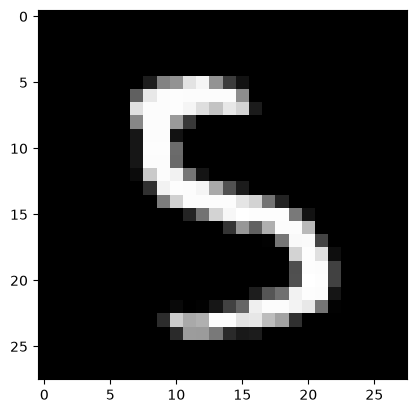

In [123]:
test_prediction(7382, W1, b1, W2, b2)

Predictions:  [9]
Label:  9


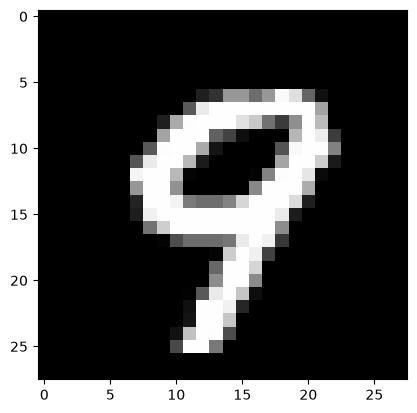

In [124]:
test_prediction(4829, W1, b1, W2, b2)


Predictions:  [9]
Label:  9


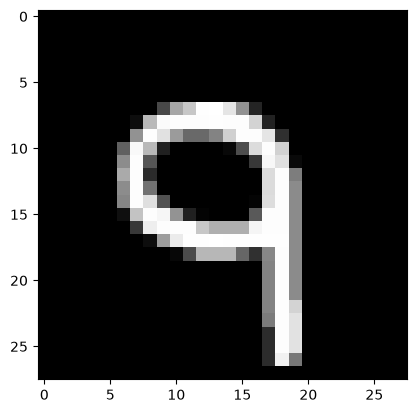

In [125]:
test_prediction(20, W1, b1, W2, b2)


Predictions:  [2]
Label:  2


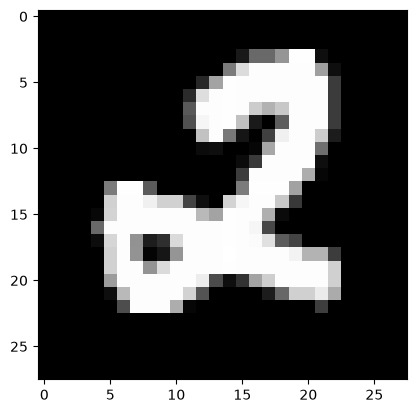

In [126]:
test_prediction(378, W1, b1, W2, b2)

In [132]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
print("Model performance on test set: ", get_accuracy(dev_predictions, Y_dev)*100)

[2 0 7 8 9 4 6 2 7 1 3 1 9 4 1 2 0 3 9 0 7 8 1 1 9 3 0 9 4 5 6 6 4 8 6 3 0
 3 4 1 1 4 5 2 2 6 1 7 1 0 1 6 8 4 9 9 4 4 4 5 5 7 5 8 4 2 6 0 4 7 4 2 3 9
 6 1 4 2 3 9 6 5 9 1 6 8 6 6 8 8 0 0 1 1 2 8 7 2 9 2 1 8 7 4 1 9 0 0 0 3 2
 2 4 9 9 4 0 0 2 2 4 0 3 6 5 6 3 2 0 1 7 1 5 6 0 1 4 7 3 3 0 7 2 9 2 1 4 4
 7 8 4 3 7 3 5 7 6 4 7 6 3 1 4 0 5 6 3 8 1 4 7 1 6 9 8 9 9 4 1 1 4 4 9 2 3
 1 6 2 3 9 0 4 2 5 8 2 3 1 9 9 7 4 5 0 9 7 7 0 7 9 6 8 3 7 5 3 1 1 7 9 6 2
 6 9 7 0 9 5 6 7 1 1 3 4 2 4 6 7 6 3 3 4 1 7 2 7 6 5 9 6 4 8 2 9 8 7 5 9 7
 5 4 8 9 4 1 1 5 7 4 2 6 2 0 9 0 2 7 3 4 7 7 6 4 6 0 8 3 7 6 3 6 3 5 4 3 1
 1 5 2 4 6 8 9 5 5 1 8 7 2 7 7 1 7 0 4 9 8 3 7 7 9 7 0 6 9 4 6 7 4 6 9 1 6
 1 4 3 4 7 1 3 1 8 4 7 5 5 3 7 9 0 2 0 8 1 9 9 5 2 5 0 6 5 8 6 7 7 0 4 7 9
 2 9 7 7 7 8 1 6 9 1 7 7 0 9 7 4 6 3 4 3 1 3 9 8 3 3 4 9 9 6 1 8 5 0 0 3 0
 4 8 8 2 6 7 2 0 1 6 2 2 2 2 0 3 8 0 7 4 7 5 6 1 1 2 9 7 4 0 4 7 7 6 6 0 5
 5 1 5 2 1 7 2 5 8 7 4 9 0 6 5 4 1 9 1 8 4 5 0 1 1 4 7 2 5 0 5 3 8 1 8 0 1
 3 4 0 5 7 8 6 1 1 2 4 8 